# Importo las librerias

In [101]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [102]:
#------Tamaño de letra en los ejes----------
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.labelsize'] = 16      # Tamaño de xlabel/ylabel
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['font.size'] = 14           # Tamaño base general

# Llamo a los datos

In [103]:
Ruta_dia3 = 'Mediciones_dia3'
Archivos_dia3 = os.listdir(Ruta_dia3)
Mediciones = []
for archivo in Archivos_dia3:
    if archivo != 'Resultados_dia3.py':
        Mediciones.append(archivo)

# Lista de concentracions


In [104]:
Concentraciones = {
    'Control': ['Control', 'vacia'],
    'Fluoresceina': [0.5, 1], # hay dos concentraciones
    'Fluo-rodamina': ['11', 0.6e-5, .75e-4, .825e-5, 1.5e-6, 1.75e-5, 1.825e-5, 3.5e-5, 3.75e-6, 4.85e-5, 4.875e-6, 0.62e-4],
    'Rodamina': [0.5e-5, 1.2e-5]
}

## Datos lampara

In [105]:
# Emision de lampara
Emision_lampara = {}
Emision_lampara_datos = pd.read_pickle('Mediciones_dia3/Control/Emision.pickle')
Emision_lampara['Intensidad'] = np.array(Emision_lampara_datos['Intensidad'].iloc[0])
Emision_lampara['err_Intensidad'] = np.array(Emision_lampara_datos['err_Intensidad'].iloc[0])
Emision_lampara['Longitud_onda'] = np.array(Emision_lampara_datos['Longitud_onda'].iloc[0])
Emision_lampara['err_Longitud_onda'] = np.array(Emision_lampara_datos['err_Longitud_onda'].iloc[0])

# Emision de lampara
Absorcion_lampara = {}
Absorcion_lampara_datos = pd.read_pickle('Mediciones_dia3/Control/Absorcion.pickle')
Absorcion_lampara['Intensidad'] = np.array(Absorcion_lampara_datos['Intensidad'].iloc[0])
Absorcion_lampara['err_Intensidad'] = np.array(Absorcion_lampara_datos['err_Intensidad'].iloc[0])
Absorcion_lampara['Longitud_onda'] = np.array(Absorcion_lampara_datos['Longitud_onda'].iloc[0])
Absorcion_lampara['err_Longitud_onda'] = np.array(Absorcion_lampara_datos['err_Longitud_onda'].iloc[0])



## Datos emision

In [106]:
Emision_datos = {}

# Busco todas las concentraciones
for concentracion in Mediciones:
    Dir_concentracion = Ruta_dia3 + f'/{concentracion}' + '/Emision.pickle'
    
    print(Dir_concentracion)
    df_Emision = pd.read_pickle(Dir_concentracion)
    
    # Valores de intensidad
    try:
        Intensidad = np.array(df_Emision['Intensidad'].iloc[0]) / Emision_lampara['Intensidad']
        #err_Intensidad = np.array(df_Emision['err_Intensidad'].iloc[0])
        var_intensidad = np.array(df_Emision['err_Intensidad'].iloc[0] / Emision_lampara['Intensidad'])**2 + (df_Emision['err_Intensidad'].iloc[0] * Emision_lampara['err_Intensidad'] / Emision_lampara['Intensidad']**2)**2
        
        err_Intensidad = np.sqrt(var_intensidad)


        # Valores de Longitud de onda
        Longitud = np.array(df_Emision['Longitud_onda'].iloc[0])
        
        
        err_Longitud = np.array(df_Emision['err_Longitud_onda'].iloc[0])
        
        #--> Agrego al diccionario los datos
        Emision_datos[f'Intensidad_{concentracion}'] = Intensidad
        Emision_datos[f'err_Intensidad_{concentracion}'] = err_Intensidad
        Emision_datos[f'Longitud_{concentracion}'] = Longitud
        Emision_datos[f'err_Longitud_{concentracion}'] = err_Longitud
    except Exception as e:
        print(f'Error {e}, con {Dir_concentracion}')
    
Emisiones = pd.DataFrame(Emision_datos)

Mediciones_dia3/Control/Emision.pickle
Mediciones_dia3/Fluoresceina_0.5mM/Emision.pickle
Mediciones_dia3/Fluoresceina_0.5mMdecantado/Emision.pickle
Mediciones_dia3/Fluoresceina_1mM/Emision.pickle
Mediciones_dia3/FluRo_11/Emision.pickle
Mediciones_dia3/Rodamina0.5e-5/Emision.pickle
Mediciones_dia3/Rodamina1.2e-5M/Emision.pickle
Error 'Intensidad', con Mediciones_dia3/Rodamina1.2e-5M/Emision.pickle
Mediciones_dia3/Ro_0.6e-5_flu/Emision.pickle
Mediciones_dia3/Ro_0.75e-4_flu/Emision.pickle
Mediciones_dia3/Ro_0.825e-5_flu/Emision.pickle
Mediciones_dia3/Ro_062e-4_flu/Emision.pickle
Mediciones_dia3/Ro_1.5e-6M_flu/Emision.pickle
Mediciones_dia3/Ro_1.75e-5_flu/Emision.pickle
Mediciones_dia3/Ro_1.825e-5_flu/Emision.pickle
Mediciones_dia3/Ro_3.5e-5_Flu/Emision.pickle
Mediciones_dia3/Ro_3.75e-6_flu/Emision.pickle
Mediciones_dia3/Ro_4.85e-5_Flu/Emision.pickle
Mediciones_dia3/Ro_4.875e-6_Flue/Emision.pickle
Error 'Intensidad', con Mediciones_dia3/Ro_4.875e-6_Flue/Emision.pickle
Mediciones_dia3/Vacia

## Datos abosorcion

In [107]:
Absorcion_datos = {}

# Busco todas las concentraciones
for concentracion in Mediciones:
    Dir_concentracion = Ruta_dia3 + f'/{concentracion}' + '/Absorcion.pickle'
    
    df_Absorcion = pd.read_pickle(Dir_concentracion)
    
    try:
        # Valores de intensidad
        Intensidad = np.array(df_Absorcion['Intensidad'].iloc[0]) / Absorcion_lampara['Intensidad']
        
        var_intensidad = np.array(df_Absorcion['err_Intensidad'].iloc[0] / Absorcion_lampara['Intensidad'])**2 + (df_Absorcion['err_Intensidad'].iloc[0] * Absorcion_lampara['err_Intensidad'] / Absorcion_lampara['Intensidad']**2)**2
        
        err_Intensidad = np.array(df_Absorcion['err_Intensidad'].iloc[0])


        # Valores de Longitud de onda
        Longitud = np.array(df_Absorcion['Longitud_onda'].iloc[0])
        err_Longitud = np.array(df_Absorcion['err_Longitud_onda'].iloc[0])
        
        #--> Agrego al diccionario los datos
        Absorcion_datos[f'Intensidad_{concentracion}'] = Intensidad
        Absorcion_datos[f'err_Intensidad_{concentracion}'] = err_Intensidad
        Absorcion_datos[f'Longitud_{concentracion}'] = Longitud
        Absorcion_datos[f'err_Longitud_{concentracion}'] = err_Longitud
    except Exception as e:
        print(f'Error {e}, con {Dir_concentracion}')
    
Absorciones = pd.DataFrame(Absorcion_datos)

# Figuras

In [108]:
a = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
a[a < 5]

array([0, 1, 2, 3, 4])

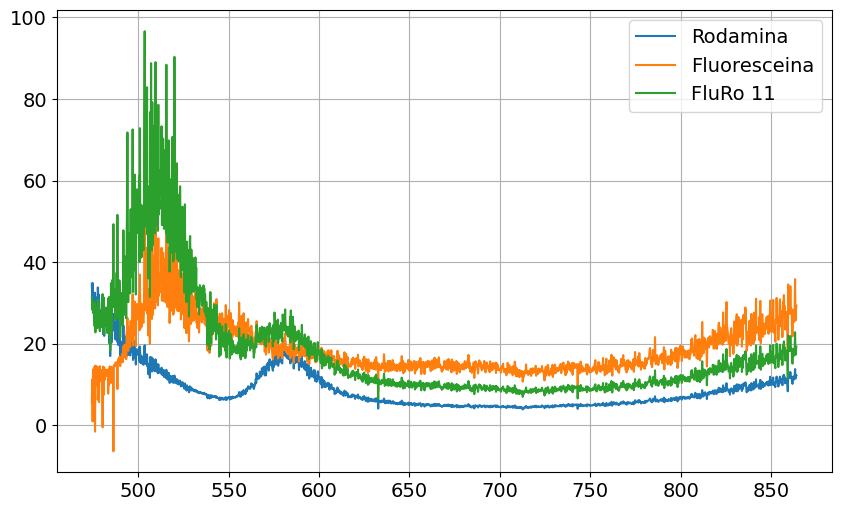

In [109]:
plt.figure(figsize = (10, 6))

a, b = 1_300, 3_000
# Rodamina absorcion
plt.plot(Emision_datos['Longitud_Rodamina0.5e-5'][a:b], Emision_datos['Intensidad_Rodamina0.5e-5'][a:b] / Emision_lampara['Intensidad'][a:b],
         label = 'Rodamina')

# Fluo emision
plt.plot(Emision_datos['Longitud_Fluoresceina_1mM'][a:b], Emision_datos['Intensidad_Fluoresceina_1mM'][a:b] / Emision_lampara['Intensidad'][a:b],
         label = 'Fluoresceina')

# Ambas
plt.plot(Emision_datos['Longitud_FluRo_11'][a:b], Emision_datos['Intensidad_FluRo_11'][a:b] / Emision_lampara['Intensidad'][a:b],
         label = 'FluRo 11')


plt.grid(), plt.legend(loc = 'upper right')
plt.show()

<Figure size 1000x600 with 0 Axes>

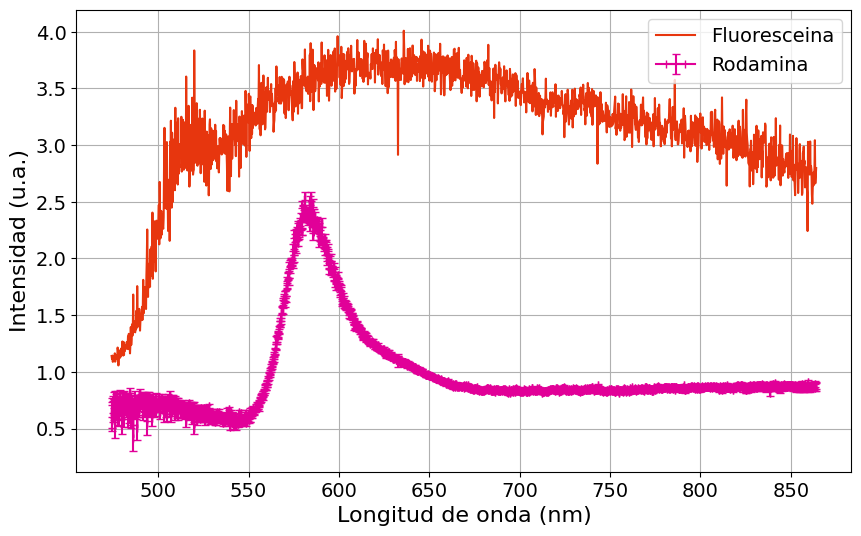

In [110]:
plt.figure(figsize = (10, 6))
fig, axs = plt.subplots(1, 1, figsize = (10, 6))

a, b = 1_300, 3_000
# Rodamina emision
axs.errorbar(Emision_datos['Longitud_Rodamina0.5e-5'][a:b], Emision_datos['Intensidad_Rodamina0.5e-5'][a:b],
             xerr = Emision_datos['err_Longitud_Rodamina0.5e-5'][a:b], yerr = Emision_datos['err_Intensidad_Rodamina0.5e-5'][a:b], label = 'Rodamina', color = '#E10098', capsize = 3)

# Fluo emision
#axs.errorbar(Emision_datos['Longitud_Fluoresceina_1mM'][a:b], Emision_datos['Intensidad_Fluoresceina_0.5mM'][a:b],
#             xerr = Emision_datos['err_Longitud_Fluoresceina_1mM'][a:b], yerr = Emision_datos['Intensidad_Fluoresceina_0.5mM'][a:b],
#             label = 'Fluoresceina',color = "#E7360EFF")
axs.plot(Emision_datos['Longitud_Fluoresceina_1mM'][a:b], Emision_datos['Intensidad_Fluoresceina_0.5mM'][a:b],
             label = 'Fluoresceina', color = "#E7360EFF")

# Ambas
"""
axs.errorbar(Emision_datos['Longitud_FluRo_11'][a:b], Emision_datos['Intensidad_FluRo_11'][a:b],
             xerr = Emision_datos['err_Longitud_FluRo_11'][a:b], yerr = Emision_datos['err_Intensidad_FluRo_11'][a:b], 
             label = 'Mezcla 1:1')
"""
axs.set(xlabel = 'Longitud de onda (nm)', ylabel = 'Intensidad (u.a.)')
plt.grid(), plt.legend(loc = 'upper right'), plt.savefig('Figuras_informe/Fret/Comp1.pdf', bbox_inches = 'tight')
plt.show()

In [111]:
# Defino las concentraciones en orden y calculo la fluorescencia del donor sin acepptor
concentraciones = np.array(['3.75e-6','0.5e-5','0.6e-5','0.825e-5','1.75e-5','1.825e-5','4.85e-5','0.75e-4'])
# '1.5e-6','0.5e-5'


In [112]:
# Calculo para cada concentracion de acceptor la florescencia del donor
F_das = []
err_F_das = []

for concentracion in concentraciones:
    if concentracion == '0.62e-4':
        F_das.append(Emision_datos[f'Intensidad_Ro_062e-4_flu'])
        err_F_das.append(Emision_datos[f'err_Intensidad_Ro_062e-4_flu'])
    elif concentracion == '1.5e-6':
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}M_flu'])
        err_F_das.append(Emision_datos[f'err_Intensidad_Ro_{concentracion}M_flu'])
    elif concentracion == '3.5e-5' or concentracion == '4.85e-5':
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}_Flu'])
        err_F_das.append(Emision_datos[f'err_Intensidad_Ro_{concentracion}_Flu'])
    elif concentracion == '0.5e-5':
        F_das.append(Emision_datos[f'Intensidad_Rodamina{concentracion}'])
        err_F_das.append(Emision_datos[f'err_Intensidad_Rodamina{concentracion}'])
    else:
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}_flu'])
        err_F_das.append(Emision_datos[f'err_Intensidad_Ro_{concentracion}_flu'])
    

F_das = np.array(F_das)
err_F_das = np.array(err_F_das)


<Figure size 1000x600 with 0 Axes>

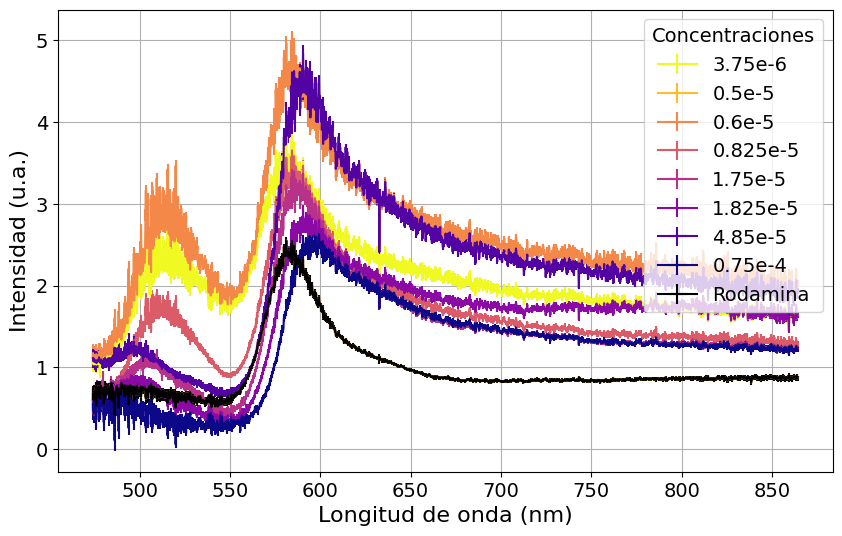

In [115]:
plt.figure(figsize = (10, 6))
fig, axs = plt.subplots(1, 1, figsize = (10, 6))

a, b = 1_300, 3_000
cmap = plt.cm.plasma_r  

# Concentraciones
for i in np.arange(0,len(F_das)):
    axs.errorbar(Emision_datos['Longitud_FluRo_11'][a:b], F_das[i][a:b],
                 xerr = Emision_datos['err_Longitud_FluRo_11'][a:b], yerr = err_F_das[i][a:b],
                 label = f'{concentraciones[i]}',color = cmap(i/7))
    
# Rodamina emision
axs.errorbar(Emision_datos['Longitud_Rodamina0.5e-5'][a:b], Emision_datos['Intensidad_Rodamina0.5e-5'][a:b],
             xerr = Emision_datos['err_Longitud_Rodamina0.5e-5'][a:b], yerr = Emision_datos['err_Intensidad_Rodamina0.5e-5'][a:b],
             label = 'Rodamina',color = 'black')

axs.set(xlabel = 'Longitud de onda (nm)', ylabel = 'Intensidad (u.a.)')
plt.grid(), plt.legend(loc = 'upper right', title = 'Concentraciones')
plt.savefig('Figuras_informe/Fret/Fret_concentraciones.pdf', bbox_inches = 'tight')
plt.show()


# Analisis de eficiciencia

$E = 1 - \frac{F_{DA}}{F_D}$ 

$F_{DA}$: donor fluorescence intensities with acceptor

$F_A$: donor fluorescence intensities without an acceptor

In [ ]:
# Con esto elijo un dato fijo que corresponde a algun lambda, trato de que sea en el pico de rhodamina
posicion_lambda = 1510

In [ ]:
# Defino las concentraciones en orden y calculo la fluorescencia del donor sin acepptor
concentraciones = np.array(['3.75e-6','0.6e-5','0.825e-5','1.75e-5','1.825e-5','3.5e-5','4.85e-5','0.62e-4','0.75e-4'])
# '1.5e-6','0.5e-5'
F_a = Emision_datos['Intensidad_Fluoresceina_0.5mM'][posicion_lambda]/Emision_datos['Intensidad_Control'][posicion_lambda]


In [ ]:
# Calculo para cada concentracion de acceptor la florescencia del donor
F_das = []
for concentracion in concentraciones:
    if concentracion == '0.62e-4':
        F_das.append(Emision_datos[f'Intensidad_Ro_062e-4_flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '1.5e-6':
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}M_flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '3.5e-5' or concentracion == '4.85e-5':
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}_Flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '0.5e-5':
        F_das.append(Emision_datos[f'Intensidad_Rodamina{concentracion}']/Emision_datos['Intensidad_Control'])
    else:
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}_flu']/Emision_datos['Intensidad_Control'])
    

F_das = np.array(F_das)

# La florescencia que dije arriba para cada concentracion en la posicion elegida
F_das[:,posicion_lambda]

array([2.30436923, 2.79337817, 1.59621291, 0.82824036, 0.5598611 ,
       0.22591692, 0.90006859, 0.21209849, 0.30148567])

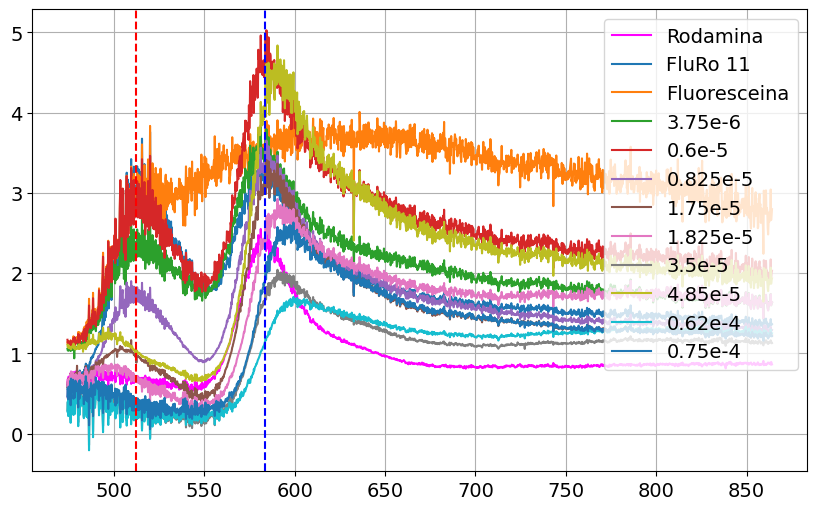

In [ ]:
plt.figure(figsize = (10, 6))

a, b = 1_300, 3_000
# Rodamina emision
plt.plot(Emision_datos['Longitud_Rodamina0.5e-5'][a:b], Emision_datos['Intensidad_Rodamina0.5e-5'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'Rodamina',c = 'magenta')

# Ambas
plt.plot(Emision_datos['Longitud_FluRo_11'][a:b], Emision_datos['Intensidad_FluRo_11'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'FluRo 11')

# Floresceina emision
plt.plot(Emision_datos['Longitud_Fluoresceina_0.5mM'][a:b], Emision_datos['Intensidad_Fluoresceina_0.5mM'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'Fluoresceina')

# Concentraciones
for i in np.arange(0,len(F_das)):
    plt.plot(Emision_datos['Longitud_FluRo_11'][a:b], F_das[i][a:b],
         label = f'{concentraciones[i]}')


plt.axvline(Emision_datos['Longitud_Control'][1470],c = 'red',linestyle = '--')
plt.axvline(Emision_datos['Longitud_Control'][1790],c = 'blue',linestyle = '--')
plt.grid(), plt.legend(loc = 'upper right')
plt.show()

In [ ]:
# Calculo cada eficiencia por concentracion el la posicion elegida
E = []
for i in F_das[:,posicion_lambda]:
    E.append(1-(i/F_a))

# Cambio las concentraciones a numeros
concentraciones = concentraciones.astype('float')
concentraciones
E

[np.float64(0.2515926714565673),
 np.float64(0.09277356064110442),
 np.float64(0.4815859258290943),
 np.float64(0.7310061482692309),
 np.float64(0.8181697001216027),
 np.float64(0.9266272610381375),
 np.float64(0.7076779533998333),
 np.float64(0.9311151795377587),
 np.float64(0.9020842311461706)]

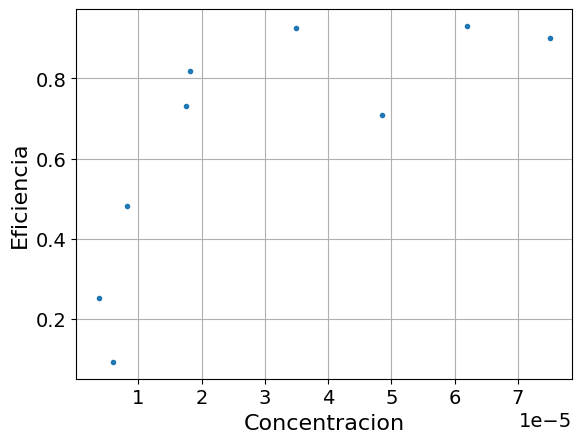

In [ ]:
plt.figure()
plt.plot(concentraciones,E,'.')
plt.xlabel('Concentracion')
plt.ylabel('Eficiencia')
plt.grid()

# Prueba

In [ ]:
posicion_lambda = 1780

In [ ]:
# Defino las concentraciones en orden y calculo la fluorescencia del donor sin acepptor
concentraciones = np.array(['3.75e-6','0.825e-5','1.75e-5','0.62e-4'])
# '1.5e-6','0.5e-5','0.6e-5','1.825e-5','3.5e-5','4.85e-5','0.75e-4'
F_a = Emision_datos['Intensidad_Ro_1.5e-6M_flu'][posicion_lambda]/Emision_datos['Intensidad_Control'][posicion_lambda]


In [ ]:
# Calculo para cada concentracion de acceptor la florescencia del donor
F_das = []
for concentracion in concentraciones:
    if concentracion == '0.62e-4':
        F_das.append(Emision_datos[f'Intensidad_Ro_062e-4_flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '1.5e-6':
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}M_flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '3.5e-5' or concentracion == '4.85e-5':
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}_Flu']/Emision_datos['Intensidad_Control'])
    elif concentracion == '0.5e-5':
        F_das.append(Emision_datos[f'Intensidad_Rodamina{concentracion}']/Emision_datos['Intensidad_Control'])
    else:
        F_das.append(Emision_datos[f'Intensidad_Ro_{concentracion}_flu']/Emision_datos['Intensidad_Control'])
    

F_das = np.array(F_das)

# La florescencia que dije arriba para cada concentracion en la posicion elegida
F_das[:,posicion_lambda]

array([3.55859853, 3.33867239, 3.02312197, 1.02711349])

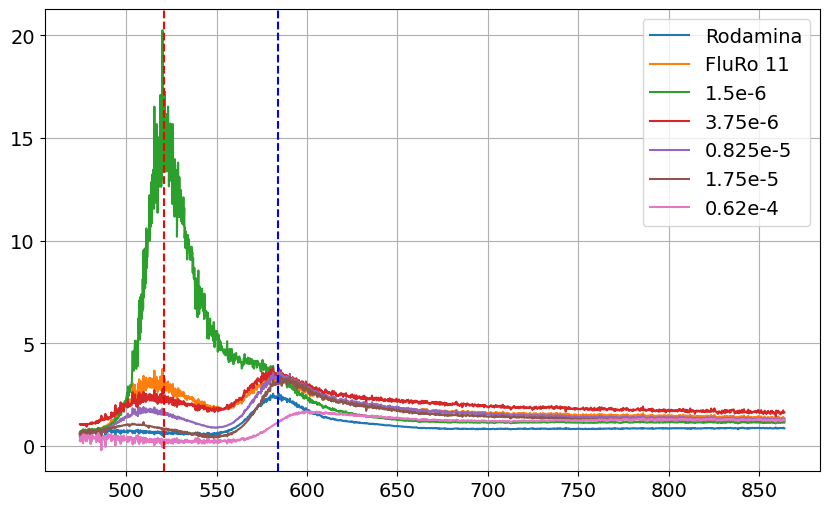

In [ ]:
plt.figure(figsize = (10, 6))

a, b = 1_300, 3_000
# Rodamina emision
plt.plot(Emision_datos['Longitud_Rodamina0.5e-5'][a:b], Emision_datos['Intensidad_Rodamina0.5e-5'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'Rodamina')

# Ambas
plt.plot(Emision_datos['Longitud_FluRo_11'][a:b], Emision_datos['Intensidad_FluRo_11'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = 'FluRo 11')

# Floresceina emision
#plt.plot(Emision_datos['Longitud_Fluoresceina_0.5mM'][a:b], Emision_datos['Intensidad_Fluoresceina_0.5mM'][a:b] / Emision_datos['Intensidad_Control'][a:b],
#         label = 'Fluoresceina')

plt.plot(Emision_datos['Longitud_Ro_1.5e-6M_flu'][a:b], Emision_datos['Intensidad_Ro_1.5e-6M_flu'][a:b] / Emision_datos['Intensidad_Control'][a:b],
         label = '1.5e-6')

# Concentraciones
for i in np.arange(0,len(F_das)):
    plt.plot(Emision_datos['Longitud_FluRo_11'][a:b], F_das[i][a:b],
         label = f'{concentraciones[i]}')


plt.axvline(Emision_datos['Longitud_Control'][1510],c = 'red',linestyle = '--')
plt.axvline(Emision_datos['Longitud_Control'][1790],c = 'blue',linestyle = '--')
plt.grid(), plt.legend(loc = 'upper right')
plt.show()

In [ ]:
# Calculo cada eficiencia por concentracion el la posicion elegida
E = []
for i in F_das[:,posicion_lambda]:
    E.append(1-(i/F_a))

# Cambio las concentraciones a numeros
concentraciones = concentraciones.astype('float')
concentraciones
E

[np.float64(0.018772130970599155),
 np.float64(0.07941332282002),
 np.float64(0.1664214132616607),
 np.float64(0.7167895255801009)]

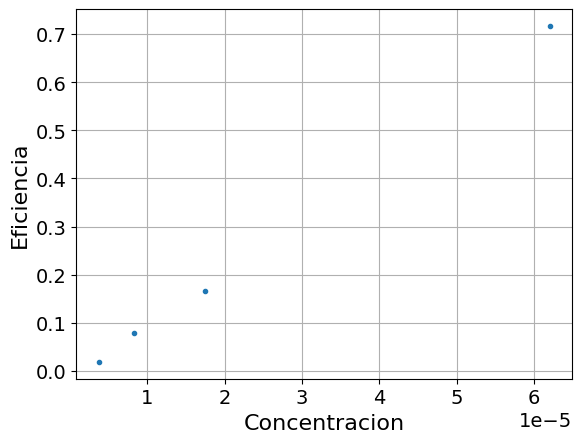

In [ ]:
plt.figure()
plt.plot(concentraciones,E,'.')
plt.xlabel('Concentracion')
plt.ylabel('Eficiencia')
plt.grid()

# Espectro de rhodamina, fluoresceina y mezcla
Esta parte es si usamos el de menor concnetracion en vez del real de flouresceina

<Figure size 1000x600 with 0 Axes>

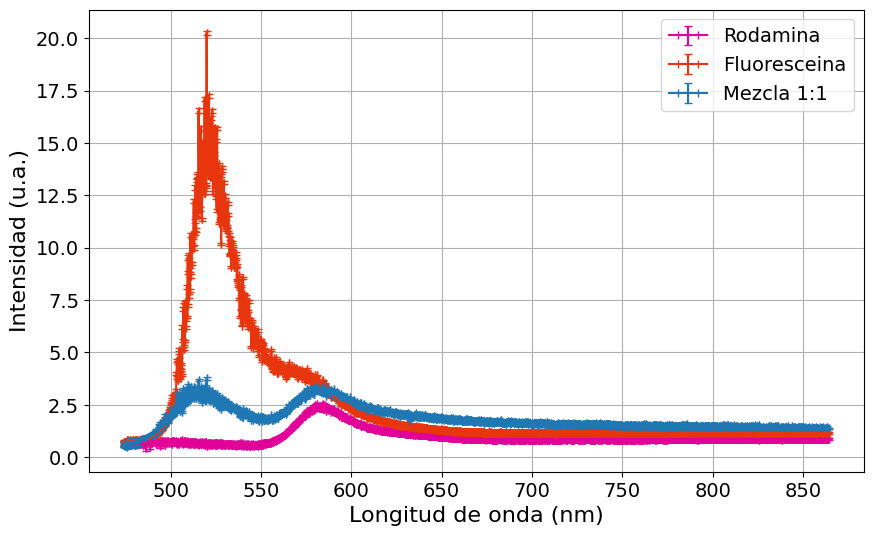

In [ ]:
plt.figure(figsize = (10, 6))
fig, axs = plt.subplots(1, 1, figsize = (10, 6))
a, b = 1_300, 3_000
# Rodamina emision
axs.errorbar(Emision_datos['Longitud_Rodamina0.5e-5'][a:b], Emision_datos['Intensidad_Rodamina0.5e-5'][a:b],
             xerr = Emision_datos['err_Longitud_Rodamina0.5e-5'][a:b], yerr = Emision_datos['err_Intensidad_Rodamina0.5e-5'][a:b],
             label = 'Rodamina',color = '#E10098', capsize = 3)

# Fluo emision
axs.errorbar(Emision_datos['Longitud_Ro_1.5e-6M_flu'][a:b], Emision_datos['Intensidad_Ro_1.5e-6M_flu'][a:b], 
             xerr = Emision_datos['err_Longitud_Ro_1.5e-6M_flu'][a:b], yerr = Emision_datos['err_Intensidad_Ro_1.5e-6M_flu'][a:b], 
             label = 'Fluoresceina',color = "#E7360EFF", capsize = 3)

# Ambas
axs.errorbar(Emision_datos['Longitud_FluRo_11'][a:b], Emision_datos['Intensidad_FluRo_11'][a:b], 
             xerr = Emision_datos['err_Longitud_FluRo_11'][a:b], yerr = Emision_datos['err_Intensidad_FluRo_11'][a:b], 
             label = 'Mezcla 1:1', capsize = 3)

axs.set(xlabel = 'Longitud de onda (nm)', ylabel = 'Intensidad (u.a.)')
plt.grid(), plt.legend(loc = 'upper right')
plt.savefig('Figuras_informe/Fret/efecto_fret1.pdf', bbox_inches = 'tight')
plt.show()

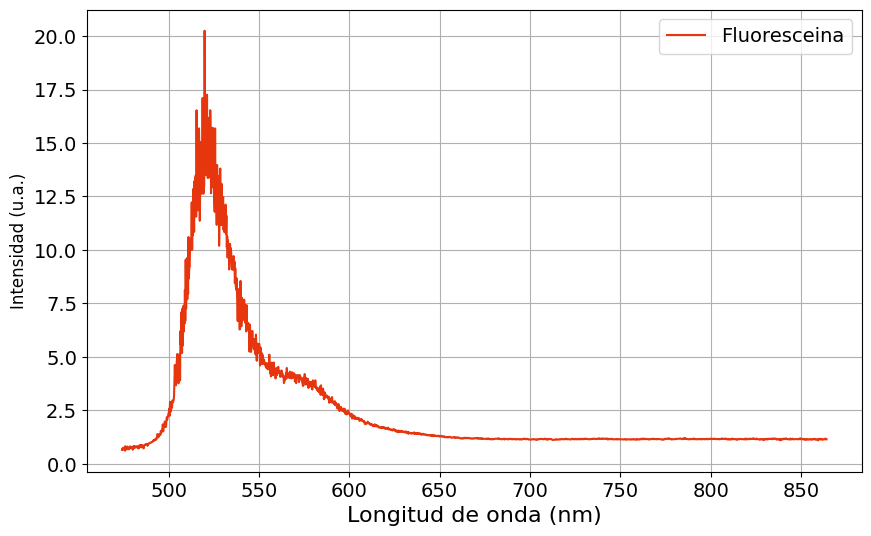

In [ ]:
plt.figure(figsize = (10, 6))

a, b = 1_300, 3_000


# Fluo emision
plt.plot(Emision_datos['Longitud_Ro_1.5e-6M_flu'][a:b],
        Emision_datos['Intensidad_Ro_1.5e-6M_flu'][a:b] / Emision_datos['Intensidad_Control'][a:b],
        label = 'Fluoresceina',color = "#E7360EFF")



plt.xlabel('Longitud de onda (nm)'), plt.ylabel('Intensidad (u.a.)',fontsize = 12)
plt.grid(), plt.legend(loc = 'upper right')
plt.show()

Intensidad comparativa Fluoresceina vs absorcion rodaminna

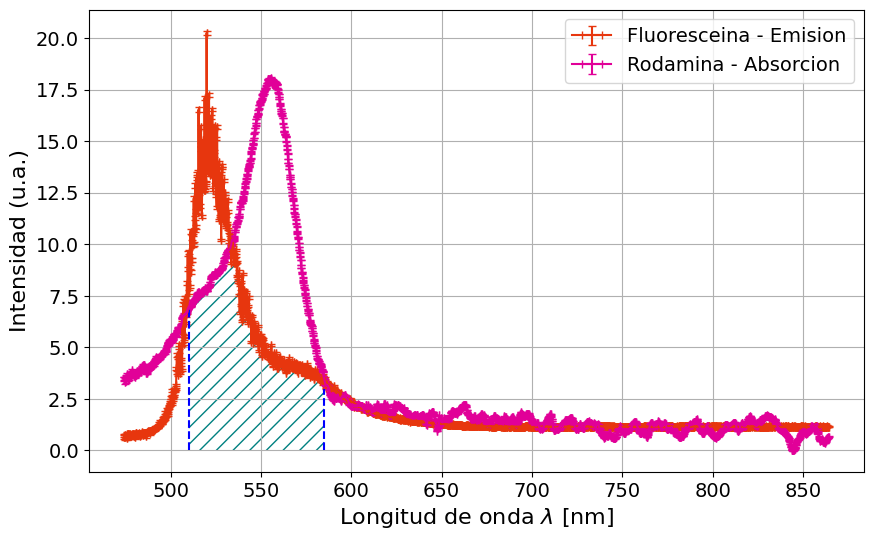

In [ ]:

plt.figure(figsize = (10, 6))

#plt.plot(Emision_datos['Longitud_Ro_1.5e-6M_flu'][a:b],
#        (Emision_datos['Intensidad_Ro_1.5e-6M_flu'][a:b] / Emision_datos['Intensidad_Control'][a:b]),
#        label = 'Fluoresceina - Emision',color = "#E7360EFF")

#plt.plot(Absorcion_datos['Longitud_Rodamina0.5e-5'][a:b],
#        -np.log10(Absorcion_datos['Intensidad_Rodamina0.5e-5'][a:b] / Absorcion_datos['Intensidad_Control'][a:b]) *40 - min(-np.log10(Absorcion_datos['Intensidad_Rodamina0.5e-5'][a:b] / #Absorcion_datos['Intensidad_Control'][a:b]) *40),
#         label = 'Rodamina - Absorcion',color = '#E10098')

plt.errorbar(Emision_datos['Longitud_Ro_1.5e-6M_flu'][a:b], 
             (Emision_datos['Intensidad_Ro_1.5e-6M_flu'][a:b] / Emision_datos['Intensidad_Control'][a:b]),
             yerr = Emision_datos['err_Intensidad_Ro_1.5e-6M_flu'][a:b], xerr = Emision_datos['err_Longitud_Ro_1.5e-6M_flu'][a:b],
             label = 'Fluoresceina - Emision', color = "#E7360EFF", capsize = 3)

var_absorcion = ( (Emision_datos['err_Intensidad_Ro_1.5e-6M_flu'][a:b] / Emision_datos['Intensidad_Ro_1.5e-6M_flu'][a:b])**2 + (Emision_datos['err_Intensidad_Control'][a:b] / Emision_datos['Intensidad_Control'][a:b])**2 ) / (np.log(10))**2

plt.errorbar(Absorcion_datos['Longitud_Rodamina0.5e-5'][a:b],
        -np.log10(Absorcion_datos['Intensidad_Rodamina0.5e-5'][a:b] / Absorcion_datos['Intensidad_Control'][a:b]) *40 - min(-np.log10(Absorcion_datos['Intensidad_Rodamina0.5e-5'][a:b] / Absorcion_datos['Intensidad_Control'][a:b]) *40),
        yerr = var_absorcion**(1/2), xerr = Absorcion_datos['err_Longitud_Rodamina0.5e-5'][a:b], label = 'Rodamina - Absorcion',color = '#E10098', capsize = 3)



x = Emision_datos['Longitud_Ro_1.5e-6M_flu'][a:b]

y_em = (Emision_datos['Intensidad_Ro_1.5e-6M_flu'][a:b] /
        Emision_datos['Intensidad_Control'][a:b])

y_abs = -np.log10(Absorcion_datos['Intensidad_Rodamina0.5e-5'][a:b] /
                   Absorcion_datos['Intensidad_Control'][a:b]) * 40
y_abs -= y_abs.min()

lambda_min, lambda_max = 510, 585

#plt.plot(x, y_em, label='Fluoresceina - Emision', color="#E7360EFF")
#plt.plot(x, y_abs, label='Rodamina - Absorcion', color="#E10098")

# Para la región por debajo de ambas:
y_lower = np.minimum(y_em, y_abs)

plt.fill_between(
    x,
    0,
    y_lower,
    where=(x >= lambda_min) & (x <= lambda_max),
    hatch='//',         # patrón de rayas
    facecolor='none',    # sin color sólido
    edgecolor='teal',    # color de las rayas
    linewidth=0.0
)

plt.plot([lambda_min, lambda_min], [0, 7.0], color = 'blue', linestyle = '--')
plt.plot([lambda_max, lambda_max], [0, 3], color = 'blue', linestyle = '--')

#plt.axvline(lambda_min, color='blue')
#plt.axvline(lambda_max, color='blue')
plt.xlabel(r'Longitud de onda $\lambda$ [nm]'), plt.ylabel('Intensidad (u.a.)')
plt.grid()
plt.legend(), plt.savefig('Figura_charla/solpamiento.png')
plt.savefig('Figuras_informe/Fret/solapamiento.pdf', bbox_inches = 'tight')
plt.show()


